In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r"C:\Users\shalini\OneDrive\Desktop\LAYOFF\layoffs project.csv")

In [4]:
df.shape

(4554, 11)

In [5]:
df.columns

Index(['company', 'location', 'total_laid_off', 'date', 'percentage_laid_off',
       'industry', 'source', 'stage', 'funds_raised', 'country', 'date_added'],
      dtype='object')

In [6]:
df.dtypes

company                 object
location                object
total_laid_off         float64
date                    object
percentage_laid_off    float64
industry                object
source                  object
stage                   object
funds_raised           float64
country                 object
date_added              object
dtype: object

In [7]:
df.isnull().sum()

company                   0
location                  1
total_laid_off         1576
date                      0
percentage_laid_off    1697
industry                  2
source                    3
stage                     8
funds_raised            540
country                   2
date_added                0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df[df.isnull().any(axis=1)].head(10)

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
1,TikTok,Nashville,250.0,8/6/2026,NaN,Consumer,https://www.nytimes.com/2026/08/05/technology/...,Acquired,NaN,United States,8/6/2026
3,Google,SF Bay Area,52.0,8/5/2026,NaN,Consumer,https://www.geekwire.com/2026/google-to-cut-52...,Post-IPO,26.0,United States,8/6/2026
4,LegalZoom,Austin,NaN,8/5/2026,0.13,Legal,https://finance.yahoo.com/markets/stocks/artic...,Post-IPO,952.0,United States,8/7/2026
6,80 Acres Farms,Cincinnati,NaN,8/4/2026,1.00,Food,https://agfundernews.com/indoor-ag-heavyweight...,Unknown,275.0,United States,8/4/2026
7,jalebi.io,"Dubai, Non-U.S.",NaN,8/4/2026,1.00,Food,https://jawlah.co/en/61711,Seed,NaN,UAE,8/4/2026
8,Nutanix,SF Bay Area,NaN,8/4/2026,0.05,Infrastructure,https://www.crn.com/news/cloud/2026/nutanix-to...,Post-IPO,1100.0,United States,8/4/2026
9,FalconX,SF Bay Area,NaN,8/3/2026,0.10,Crypto,https://cryptobriefing.com/falconx-cuts-workfo...,Series D,477.0,United States,8/3/2026
10,Pump.fun,San Diego,40.0,8/1/2026,NaN,Crypto,https://www.kucoin.com/news/flash/pump-fun-emp...,Unknown,NaN,United States,8/3/2026
14,Reforged Labs,"Singapore, Non-U.S.",NaN,7/31/2026,1.00,Marketing,https://www.techinasia.com/ai-ad-startup-refor...,Seed,4.0,Singapore,8/2/2026
15,GoLemon,"Lagos, Non-U.S.",33.0,7/30/2026,1.00,Retail,https://nairametrics.com/2026/07/30/nigerian-s...,Unknown,NaN,Nigeria,7/30/2026


In [10]:
df[df['total_laid_off'].isna() & df['percentage_laid_off'].isna()].shape

(741, 11)

In [11]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [12]:
df['date'].dtype

dtype('<M8[ns]')

In [13]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [14]:
df['date_added'].dtype

dtype('<M8[ns]')

In [15]:
df[['date', 'date_added']].isnull().sum()

date          0
date_added    0
dtype: int64

In [16]:
df[['total_laid_off', 'percentage_laid_off', 'funds_raised']].describe()

,total_laid_off,percentage_laid_off,funds_raised
count,2978.000000,2857.000000,4014.000000
mean,311.983546,0.293828,875.005505
std,1119.650346,0.304449,4552.427577
min,3.000000,0.000000,0.700000
25%,40.000000,0.100000,55.000000
50%,90.000000,0.170000,175.000000
75%,200.000000,0.330000,484.000000
max,22000.000000,1.000000,121900.000000


In [17]:
(df['percentage_laid_off'] == 0).sum()

np.int64(1)

In [18]:
df[df['percentage_laid_off'] == 0]

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
3611,TaskUs,Los Angeles,52.0,2022-06-21,0.0,Support,Internal memo,Post-IPO,279.0,United States,2022-06-22


In [19]:
df.loc[df['percentage_laid_off'] == 0, 'percentage_laid_off'] = np.nan

In [20]:
(df['percentage_laid_off'] == 0).sum()

np.int64(0)

In [21]:
df[['industry', 'stage', 'country']].nunique()

industry    30
stage       16
country     66
dtype: int64

In [22]:
df['industry'].value_counts(dropna=False)

industry
Finance           540
Retail            362
Healthcare        333
Consumer          314
Other             307
Transportation    274
Food              254
Marketing         221
Crypto            179
Real Estate       167
Education         165
Security          164
Media             162
Data              144
HR                115
Travel            113
Hardware           85
Infrastructure     79
Sales              77
Logistics          75
Support            67
Recruiting         59
Product            59
Energy             49
Fitness            48
AI                 35
Manufacturing      33
Construction       25
Aerospace          24
Legal              23
NaN                 2
Name: count, dtype: int64

In [23]:
df[df['industry'].isna()]

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
417,Eyeo,"Cologne, Non-U.S.",NaN,2025-07-28,0.40,NaN,https://www.adexchanger.com/privacy/eyeo-names...,Unknown,NaN,Germany,2025-07-30
1483,Appsmith,SF Bay Area,35.0,2023-09-22,0.25,NaN,https://inc42.com/buzz/exclusive-insight-partn...,Series B,51.0,United States,2023-09-24


In [24]:
df['stage'].value_counts(dropna=False)

stage
Post-IPO          1096
Unknown            768
Series B           491
Series C           452
Acquired           413
Series D           364
Series A           272
Series E           207
Seed               154
Series F           127
Private Equity      86
Series H            36
Subsidiary          31
Series G            29
Series J            11
Series I             9
NaN                  8
Name: count, dtype: int64

In [25]:
df[df['stage'].isna()]

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
163,Zondacrypto,"Tallinn, Non-U.S.",NaN,2026-04-21,NaN,Crypto,https://tvpworld.com/92834466/zonadcrypto-staf...,NaN,NaN,Estonia,2026-07-13
204,Flex AI,"Vancouver, Non-U.S.",NaN,2026-03-24,1.00,Fitness,https://betakit.com/personal-training-app-flex...,NaN,NaN,Canada,2026-07-27
216,OP Labs,New York City,20.0,2026-03-12,NaN,Crypto,https://www.cryptotimes.io/2026/03/12/op-labs-...,NaN,NaN,United States,2026-07-13
2410,Soundwide,"Berlin, Non-U.S.",NaN,2023-01-27,0.08,Other,https://cdm.link/2023/01/soundwide-layoffs/,NaN,NaN,Germany,2023-05-01
3022,Advata,Seattle,32.0,2022-10-28,0.21,Healthcare,https://www.geekwire.com/2022/seattle-area-hea...,NaN,NaN,United States,2022-10-31
3028,Spreetail,Austin,NaN,2022-10-27,NaN,Retail,https://www.wearespreetail.com/blog/a-message-...,NaN,NaN,United States,2022-10-28
3377,Gatherly,Atlanta,NaN,2022-07-31,0.50,Marketing,Company exec,NaN,NaN,United States,2022-08-02
3760,Zapp,"London, Non-U.S.",NaN,2022-05-25,0.10,Food,https://sifted.eu/articles/zapp-layoffs-staff/,NaN,300.0,United Kingdom,2022-05-27


In [26]:
categorical_cols = ['location', 'industry', 'source', 'stage', 'country']

df[categorical_cols] = df[categorical_cols].fillna('Unknown')

In [27]:
df[categorical_cols].isnull().sum()

location    0
industry    0
source      0
stage       0
country     0
dtype: int64

In [28]:
df['date'].min(), df['date'].max()

(Timestamp('2020-03-11 00:00:00'), Timestamp('2026-08-07 00:00:00'))

In [29]:
(df['total_laid_off'] < 0).sum(), (df['funds_raised'] < 0).sum()

(np.int64(0), np.int64(0))

In [30]:
((df['percentage_laid_off'] < 0) | (df['percentage_laid_off'] > 1)).sum()

np.int64(0)

In [31]:
df.dtypes

company                        object
location                       object
total_laid_off                float64
date                   datetime64[ns]
percentage_laid_off           float64
industry                       object
source                         object
stage                          object
funds_raised                  float64
country                        object
date_added             datetime64[ns]
dtype: object

In [32]:
df_clean = df.copy()

In [33]:
df_clean.shape

(4554, 11)

In [34]:
df_clean.to_csv(
    r"C:\Users\shalini\OneDrive\Desktop\LAYOFF\layoffs_clean.csv",
    index=False
)

In [35]:
pd.read_csv(
    r"C:\Users\shalini\OneDrive\Desktop\LAYOFF\layoffs_clean.csv"
).shape

(4554, 11)

In [36]:
#Analysis 1: Year-wise Layoff Trend.
df_clean.groupby(df_clean['date'].dt.year)['total_laid_off'].sum()

date
2020     80998.0
2021     15823.0
2022    165269.0
2023    265660.0
2024    152922.0
2025    122606.0
2026    125809.0
Name: total_laid_off, dtype: float64

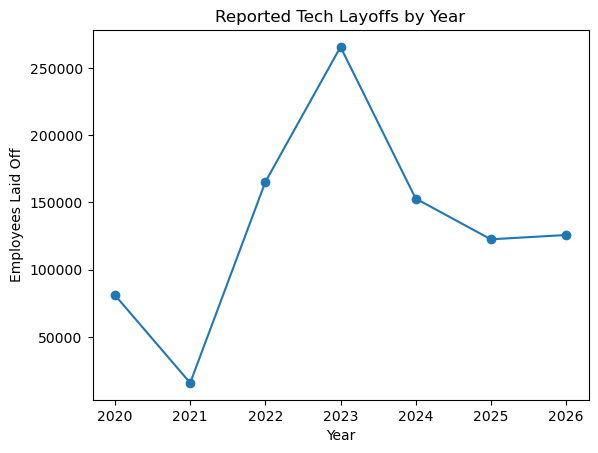

In [37]:
yearly_layoffs = (
    df_clean.groupby(df_clean['date'].dt.year)['total_laid_off']
    .sum()
)

yearly_layoffs.plot(
    kind='line',
    marker='o',
    title='Reported Tech Layoffs by Year',
    xlabel='Year',
    ylabel='Employees Laid Off'
);

In [38]:
#Analysis 2 — Which industries had the most reported layoffs?
industry_layoffs = (
    df_clean.groupby('industry')['total_laid_off']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

industry_layoffs

industry
Other             115800.0
Retail            108226.0
Hardware          105200.0
Consumer           98299.0
Finance            70162.0
Transportation     67402.0
Food               52101.0
Healthcare         40330.0
Infrastructure     24835.0
Travel             24340.0
Name: total_laid_off, dtype: float64

In [39]:
import matplotlib.pyplot as plt

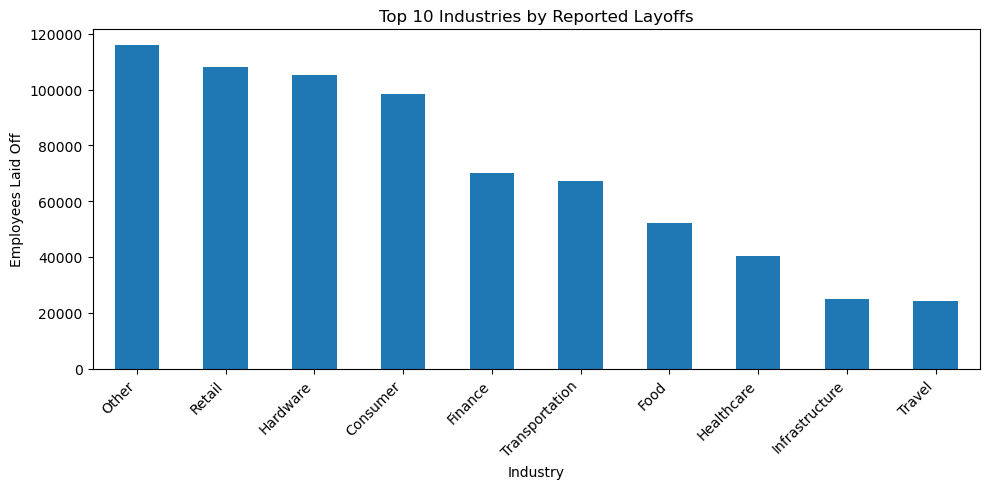

In [40]:
industry_layoffs.plot(
    kind='bar',
    figsize=(10, 5),
    title='Top 10 Industries by Reported Layoffs',
    xlabel='Industry',
    ylabel='Employees Laid Off'
);

plt.xticks(rotation=45, ha='right');
plt.tight_layout();

In [41]:
#Analysis 3 — Which companies had the biggest reported layoffs?
company_layoffs = (
    df_clean.groupby('company')['total_laid_off']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

company_layoffs

company
Amazon        59291.0
Intel         43115.0
Meta          35700.0
Microsoft     34855.0
Dell          23650.0
Oracle        22294.0
Cisco         18521.0
Salesforce    16611.0
Tesla         14500.0
Google        13749.0
Name: total_laid_off, dtype: float64

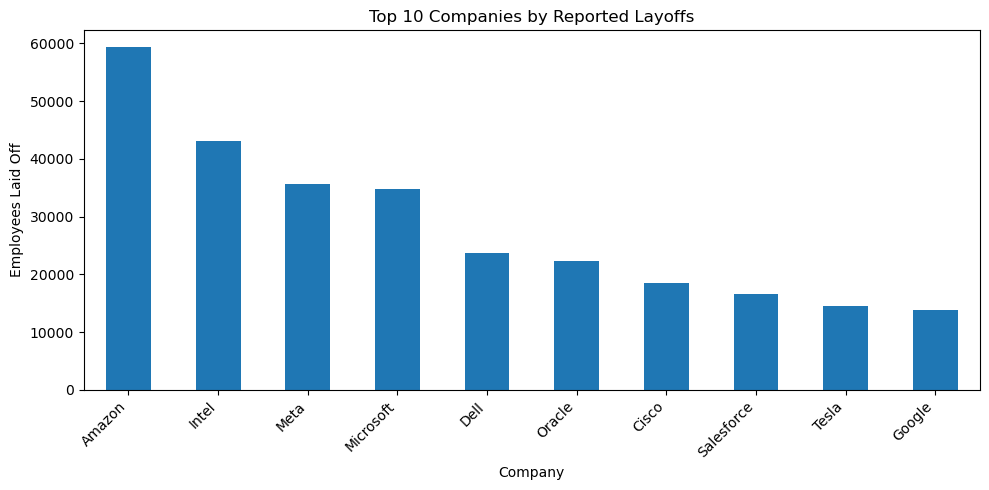

In [42]:
company_layoffs.plot(
    kind='bar',
    figsize=(10, 5),
    title='Top 10 Companies by Reported Layoffs',
    xlabel='Company',
    ylabel='Employees Laid Off'
);

plt.xticks(rotation=45, ha='right');
plt.tight_layout();

In [43]:
#Analysis 4 — Country impact
country_layoffs = (
    df_clean.groupby('country')['total_laid_off']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_layoffs

country
United States     658718.0
India              67509.0
Germany            32055.0
United Kingdom     24694.0
Netherlands        22175.0
Sweden             20379.0
Canada             16636.0
Israel             15864.0
Brazil             11939.0
China               8190.0
Name: total_laid_off, dtype: float64

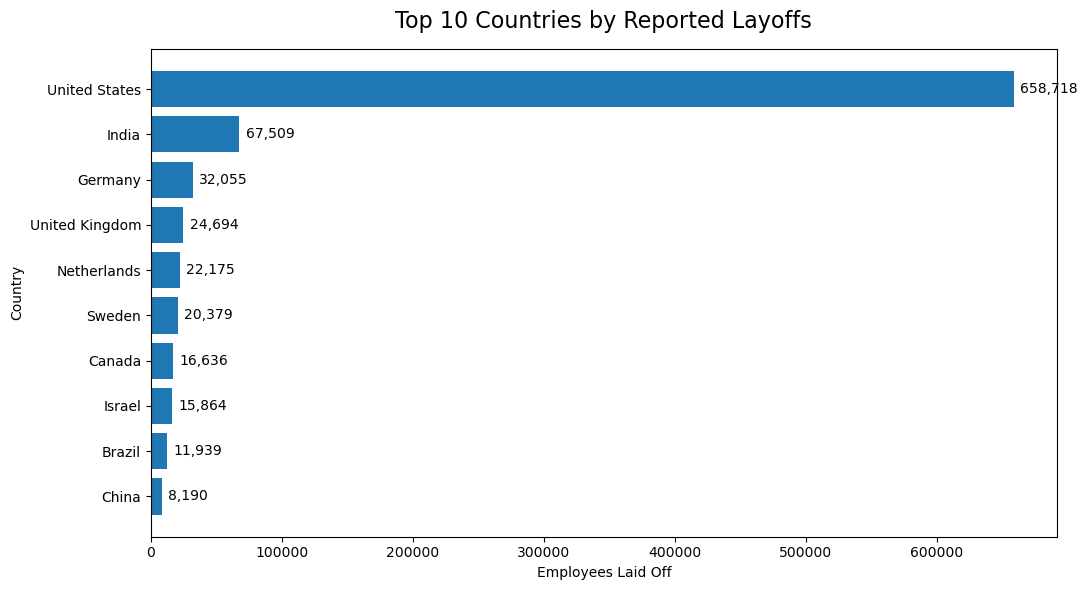

In [46]:
plt.figure(figsize=(11, 6))

bars = plt.barh(
    country_layoffs.sort_values().index,
    country_layoffs.sort_values().values
)

plt.title('Top 10 Countries by Reported Layoffs', fontsize=16, pad=15)
plt.xlabel('Employees Laid Off')
plt.ylabel('Country')

# Add numbers to the bars
for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 5000,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,.0f}',
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [47]:
#Analysis 5 — Layoff Severity: Percentage of Workforce Affected
df_clean['percentage_laid_off'].describe()

count    2856.000000
mean        0.293931
std         0.304453
min         0.010000
25%         0.100000
50%         0.170000
75%         0.330000
max         1.000000
Name: percentage_laid_off, dtype: float64

In [48]:
# high percentage impact + meaningful number of employees affected
severe_layoffs = (
    df_clean[
        (df_clean['total_laid_off'] >= 50) &
        (df_clean['percentage_laid_off'].notna())
    ]
    .sort_values('percentage_laid_off', ascending=False)
    [['company', 'total_laid_off', 'percentage_laid_off', 'industry', 'country']]
    .head(10)
)

severe_layoffs

,company,total_laid_off,percentage_laid_off,industry,country
3413,Soluto,120.0,1.0,Support,Israel
2312,Openpay,83.0,1.0,Finance,Australia
3802,SEND,300.0,1.0,Food,Australia
2513,Britishvolt,206.0,1.0,Transportation,United Kingdom
1707,DeepVerge,50.0,1.0,Healthcare,Ireland
1300,ZestMoney,150.0,1.0,Finance,India
1292,Zulily,839.0,1.0,Retail,United States
723,Eaze,500.0,1.0,Consumer,United States
3767,BeyondMinds,65.0,1.0,Data,Israel
774,Tome Biosciences,131.0,1.0,Healthcare,United States


In [49]:
# Which large layoffs represented the greatest proportion of the company's workforce?
severe_large_layoffs = (
    df_clean[
        (df_clean['total_laid_off'] >= 500) &
        (df_clean['percentage_laid_off'].notna())
    ]
    .sort_values(
        ['percentage_laid_off', 'total_laid_off'],
        ascending=[False, False]
    )
    [['company', 'total_laid_off', 'percentage_laid_off', 'industry', 'country']]
    .head(10)
)

severe_large_layoffs

,company,total_laid_off,percentage_laid_off,industry,country
3891,Katerra,2434.0,1.0,Construction,United States
625,Lilium,1000.0,1.0,Aerospace,Germany
845,Redbox,1000.0,1.0,Media,United States
3497,Butler Hospitality,1000.0,1.0,Food,United States
1806,Bitwise,900.0,1.0,Crypto,United States
1292,Zulily,839.0,1.0,Retail,United States
4102,Deliv,669.0,1.0,Retail,United States
723,Eaze,500.0,1.0,Consumer,United States
1408,Convoy,500.0,1.0,Logistics,United States
4120,Jump,500.0,1.0,Transportation,United States


In [50]:
severity = pd.cut(
    df_clean['percentage_laid_off'],
    bins=[0, 0.10, 0.25, 0.50, 0.75, 1.00],
    labels=['1–10%', '11–25%', '26–50%', '51–75%', '76–100%'],
    include_lowest=True
)

severity_counts = severity.value_counts().sort_index()

severity_counts

percentage_laid_off
1–10%       911
11–25%     1018
26–50%      479
51–75%       60
76–100%     388
Name: count, dtype: int64

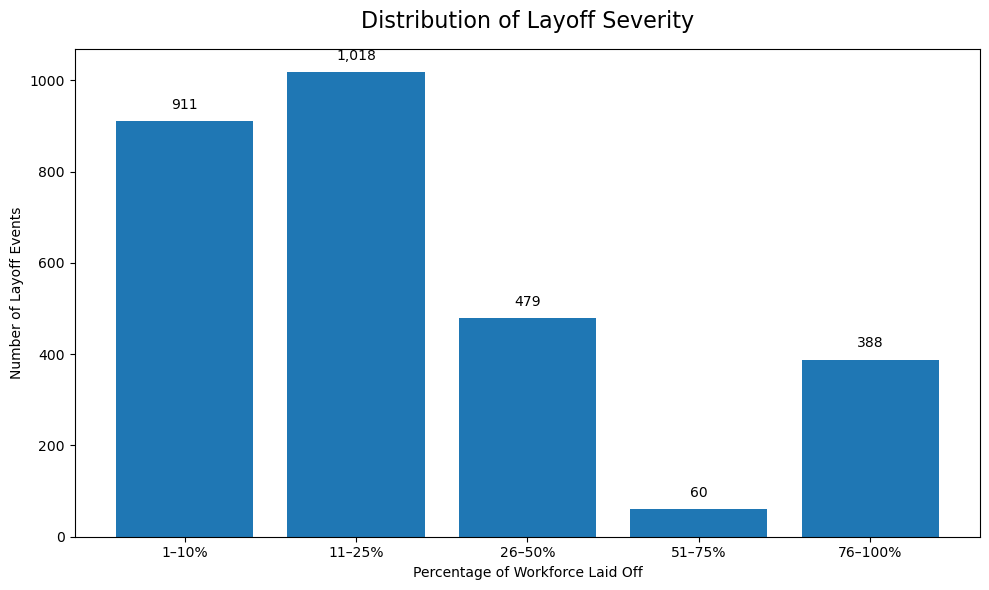

In [51]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    severity_counts.index,
    severity_counts.values
)

plt.title(
    'Distribution of Layoff Severity',
    fontsize=16,
    pad=15
)

plt.xlabel('Percentage of Workforce Laid Off')
plt.ylabel('Number of Layoff Events')

# Add exact numbers above bars
for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 20,
        f'{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [53]:
#Analysis 6 — Funding vs. Layoff Impact
df_clean[['funds_raised', 'total_laid_off']].corr()

,funds_raised,total_laid_off
funds_raised,1.000000,0.119412
total_laid_off,0.119412,1.000000


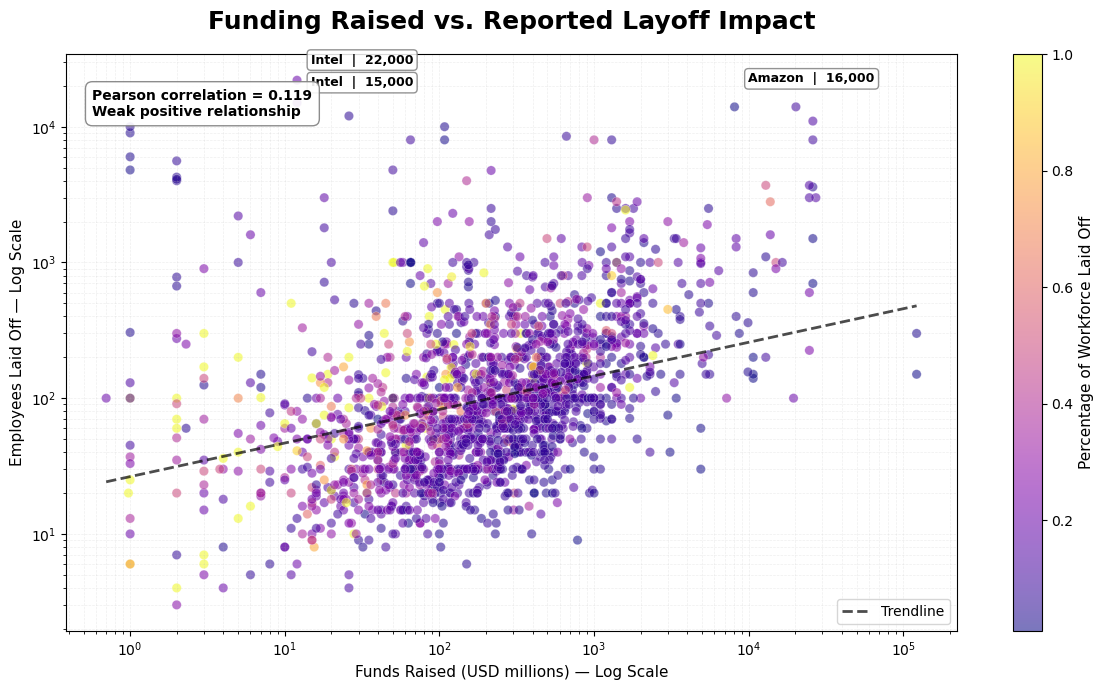

In [56]:
plt.figure(figsize=(12, 7))

# Scatter plot
scatter = plt.scatter(
    scatter_df['funds_raised'],
    scatter_df['total_laid_off'],
    c=scatter_df['percentage_laid_off'],
    cmap='plasma',
    alpha=0.55,
    s=45,
    edgecolors='white',
    linewidth=0.3
)

# Log scales
plt.xscale('log')
plt.yscale('log')

# Trendline
x_log = np.log10(scatter_df['funds_raised'])
y_log = np.log10(scatter_df['total_laid_off'])

slope, intercept = np.polyfit(x_log, y_log, 1)

x_line = np.linspace(
    x_log.min(),
    x_log.max(),
    100
)

y_line = slope * x_line + intercept

plt.plot(
    10**x_line,
    10**y_line,
    linestyle='--',
    linewidth=2,
    color='black',
    alpha=0.7,
    label='Trendline'
)

# Label only top 3 layoff events
top_3 = scatter_df.nlargest(3, 'total_laid_off')

for _, row in top_3.iterrows():

    plt.annotate(
        f"{row['company']}  |  {row['total_laid_off']:,.0f}",
        xy=(row['funds_raised'], row['total_laid_off']),
        xytext=(10, 12),
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            edgecolor='gray',
            alpha=0.85
        )
    )

# Title
plt.title(
    'Funding Raised vs. Reported Layoff Impact',
    fontsize=18,
    fontweight='bold',
    pad=18
)

plt.xlabel(
    'Funds Raised (USD millions) — Log Scale',
    fontsize=11
)

plt.ylabel(
    'Employees Laid Off — Log Scale',
    fontsize=11
)

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label(
    'Percentage of Workforce Laid Off',
    fontsize=11
)

# Correlation box
plt.text(
    0.03,
    0.94,
    f'Pearson correlation = {correlation:.3f}\nWeak positive relationship',
    transform=plt.gca().transAxes,
    fontsize=10,
    fontweight='bold',
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        edgecolor='gray',
        alpha=0.9
    )
)

# Grid
plt.grid(
    True,
    which='both',
    linestyle='--',
    linewidth=0.5,
    alpha=0.2
)

plt.legend(
    frameon=True,
    loc='lower right'
)

plt.tight_layout()
plt.show()

In [58]:
#Analysis 7 — Layoffs by Company Stage
stage_layoffs = (
    df_clean.groupby('stage')['total_laid_off']
    .sum()
    .sort_values(ascending=False)
)

stage_layoffs

stage
Post-IPO          584458.0
Unknown            82465.0
Acquired           74392.0
Series B           32770.0
Series D           27877.0
Series C           27869.0
Series E           25607.0
Series F           16904.0
Private Equity     15120.0
Series A            9247.0
Series H            8497.0
Subsidiary          7996.0
Series G            5279.0
Series J            4700.0
Series I            3155.0
Seed                2751.0
Name: total_laid_off, dtype: float64

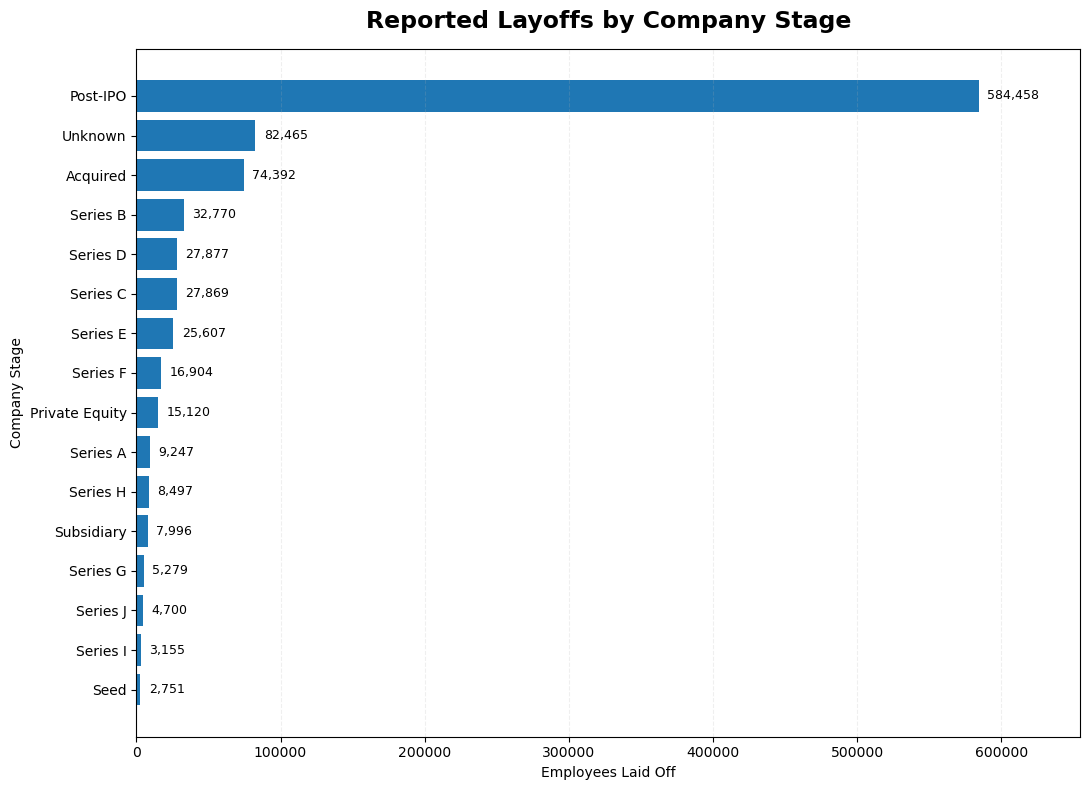

In [60]:
plt.figure(figsize=(11, 8))

stage_sorted = stage_layoffs.sort_values()

bars = plt.barh(
    stage_sorted.index,
    stage_sorted.values
)

plt.title(
    'Reported Layoffs by Company Stage',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel('Employees Laid Off')
plt.ylabel('Company Stage')

# Give labels room beyond the longest bar
plt.xlim(0, stage_sorted.max() * 1.12)

# Add exact values
for bar in bars:
    value = bar.get_width()

    plt.text(
        value + stage_sorted.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,.0f}',
        va='center',
        fontsize=9
    )

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [61]:
#Analysis 8 — Layoff Events vs. Employees Affected
yearly_events = (
    df_clean.groupby(df_clean['date'].dt.year)
    .agg(
        total_laid_off=('total_laid_off', 'sum'),
        layoff_events=('company', 'count')
    )
)

yearly_events

,total_laid_off,layoff_events
date,,
2020,80998.0,635
2021,15823.0,44
2022,165269.0,1231
2023,265660.0,1390
2024,152922.0,633
2025,122606.0,333
2026,125809.0,288


In [62]:
yearly_events['avg_layoffs_per_event'] = (
    yearly_events['total_laid_off'] /
    yearly_events['layoff_events']
)

yearly_events

,total_laid_off,layoff_events,avg_layoffs_per_event
date,,,
2020,80998.0,635,127.555906
2021,15823.0,44,359.613636
2022,165269.0,1231,134.255890
2023,265660.0,1390,191.122302
2024,152922.0,633,241.582938
2025,122606.0,333,368.186186
2026,125809.0,288,436.836806


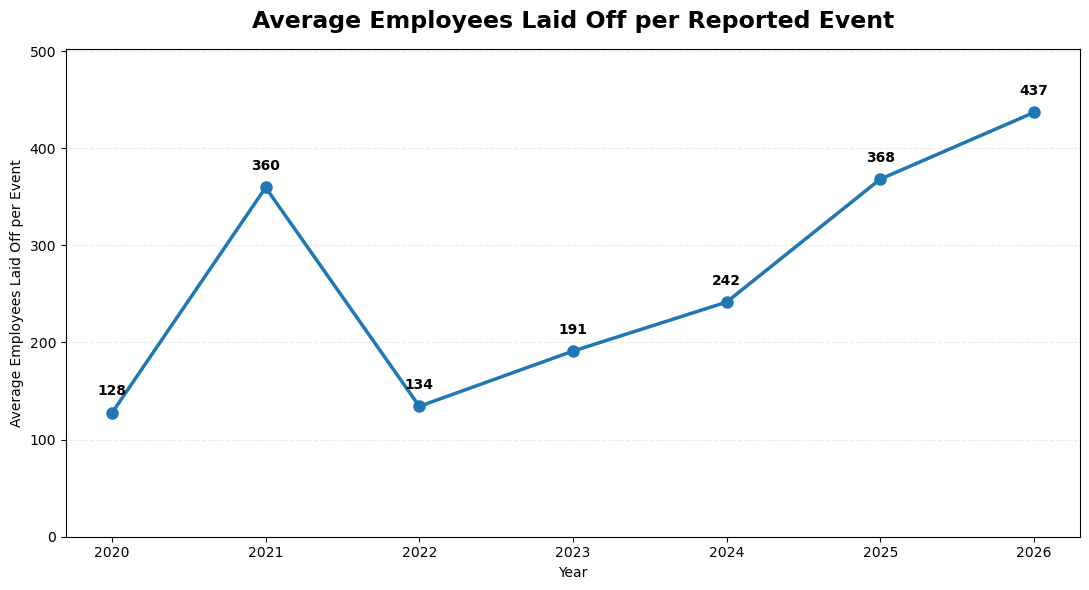

In [64]:
plt.figure(figsize=(11, 6))

years = yearly_events.index
avg_layoffs = yearly_events['avg_layoffs_per_event']

plt.plot(
    years,
    avg_layoffs,
    marker='o',
    linewidth=2.5,
    markersize=8
)

# Add exact values
for year, value in zip(years, avg_layoffs):
    plt.text(
        year,
        value + 15,
        f'{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Average Employees Laid Off per Reported Event',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel('Year')
plt.ylabel('Average Employees Laid Off per Event')

plt.xticks(years)

# Give the top label extra breathing room
plt.ylim(
    0,
    avg_layoffs.max() * 1.15
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [65]:
# Analysis 9 — Monthly Layoff Trend
monthly_layoffs = (
    df_clean.groupby(df_clean['date'].dt.to_period('M'))
    .agg(
        total_laid_off=('total_laid_off', 'sum'),
        layoff_events=('company', 'count')
    )
)

monthly_layoffs

,total_laid_off,layoff_events
date,,
2020-03,9628.0,121
2020-04,26710.0,270
2020-05,25804.0,110
2020-06,7627.0,49
2020-07,7112.0,27
...,...,...
2026-04,5085.0,36
2026-05,29002.0,50
2026-06,26460.0,50


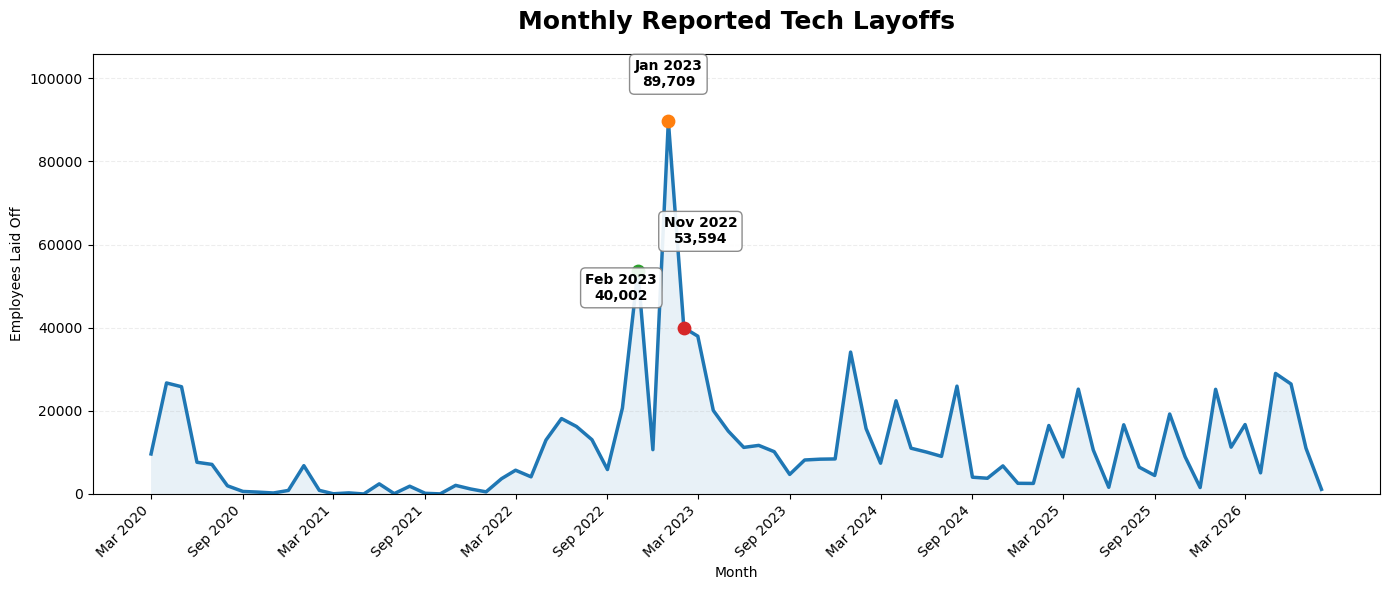

In [67]:
# Convert PeriodIndex to timestamps for cleaner plotting
monthly_plot = monthly_layoffs.copy()
monthly_plot.index = monthly_plot.index.to_timestamp()

plt.figure(figsize=(14, 6))

# Main trend
plt.plot(
    monthly_plot.index,
    monthly_plot['total_laid_off'],
    linewidth=2.5
)

# Subtle area under the line
plt.fill_between(
    monthly_plot.index,
    monthly_plot['total_laid_off'],
    alpha=0.10
)

# Identify the 3 largest months
top_3 = monthly_plot.nlargest(3, 'total_laid_off')

# Different annotation positions to avoid collision
offsets = [
    (0, 25),
    (45, 20),
    (-45, 20)
]

for (_, row), offset in zip(top_3.iterrows(), offsets):

    plt.scatter(
        row.name,
        row['total_laid_off'],
        s=80,
        zorder=3
    )

    plt.annotate(
        f"{row.name.strftime('%b %Y')}\n{row['total_laid_off']:,.0f}",
        xy=(row.name, row['total_laid_off']),
        xytext=offset,
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.35',
            facecolor='white',
            edgecolor='gray',
            alpha=0.9
        )
    )

plt.title(
    'Monthly Reported Tech Layoffs',
    fontsize=18,
    fontweight='bold',
    pad=18
)

plt.xlabel('Month')
plt.ylabel('Employees Laid Off')

# Show only every 6 months on x-axis
plt.xticks(
    monthly_plot.index[::6],
    [d.strftime('%b %Y') for d in monthly_plot.index[::6]],
    rotation=45,
    ha='right'
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.22
)

plt.ylim(
    0,
    monthly_plot['total_laid_off'].max() * 1.18
)

plt.tight_layout()
plt.show()

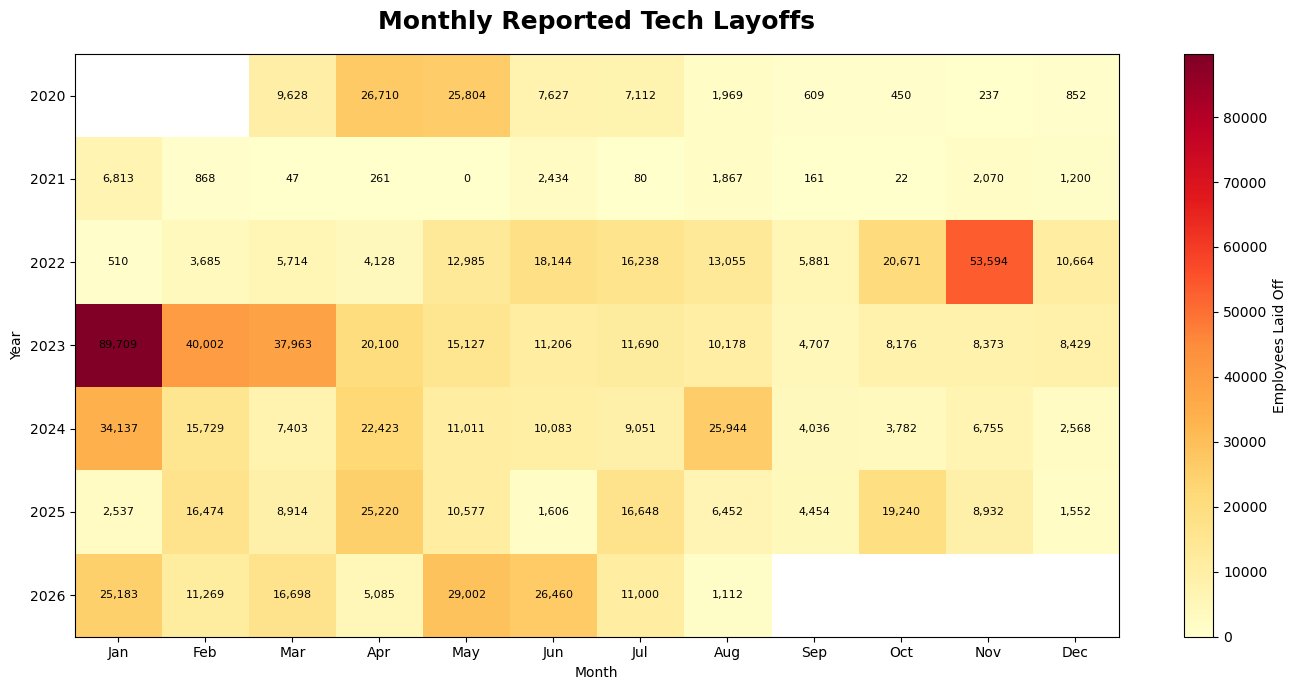

In [69]:
# Prepare monthly data
monthly_plot = monthly_layoffs.copy()

monthly_plot['year'] = monthly_plot.index.year
monthly_plot['month'] = monthly_plot.index.month

# Create pivot table
monthly_heatmap = monthly_plot.pivot(
    index='year',
    columns='month',
    values='total_laid_off'
)

# Month names
month_names = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

plt.figure(figsize=(14, 7))

# Heatmap
plt.imshow(
    monthly_heatmap,
    aspect='auto',
    cmap='YlOrRd'
)

# Axis labels
plt.xticks(
    range(12),
    month_names
)

plt.yticks(
    range(len(monthly_heatmap.index)),
    monthly_heatmap.index
)

plt.xlabel('Month')
plt.ylabel('Year')

plt.title(
    'Monthly Reported Tech Layoffs',
    fontsize=18,
    fontweight='bold',
    pad=18
)

# Add actual numbers inside cells
for i in range(len(monthly_heatmap.index)):
    for j in range(12):

        value = monthly_heatmap.iloc[i, j]

        if not np.isnan(value):
            plt.text(
                j,
                i,
                f'{value:,.0f}',
                ha='center',
                va='center',
                fontsize=8
            )

# Colorbar
cbar = plt.colorbar()
cbar.set_label('Employees Laid Off')

plt.tight_layout()
plt.show()

In [70]:
# Analysis 10 — Location-Level Impact
location_layoffs = (
    df_clean.groupby('location')['total_laid_off']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

location_layoffs

location
SF Bay Area            309979.0
Seattle                108783.0
Austin                  46353.0
New York City           42070.0
Bengaluru, Non-U.S.     35885.0
Sacramento              27582.0
London, Non-U.S.        23444.0
Boston                  22476.0
Stockholm, Non-U.S.     20167.0
Amsterdam, Non-U.S.     20095.0
Berlin, Non-U.S.        15410.0
Los Angeles             14559.0
Tel Aviv, Non-U.S.      13972.0
Walldorf, Non-U.S.      11000.0
Chicago                 10235.0
Name: total_laid_off, dtype: float64

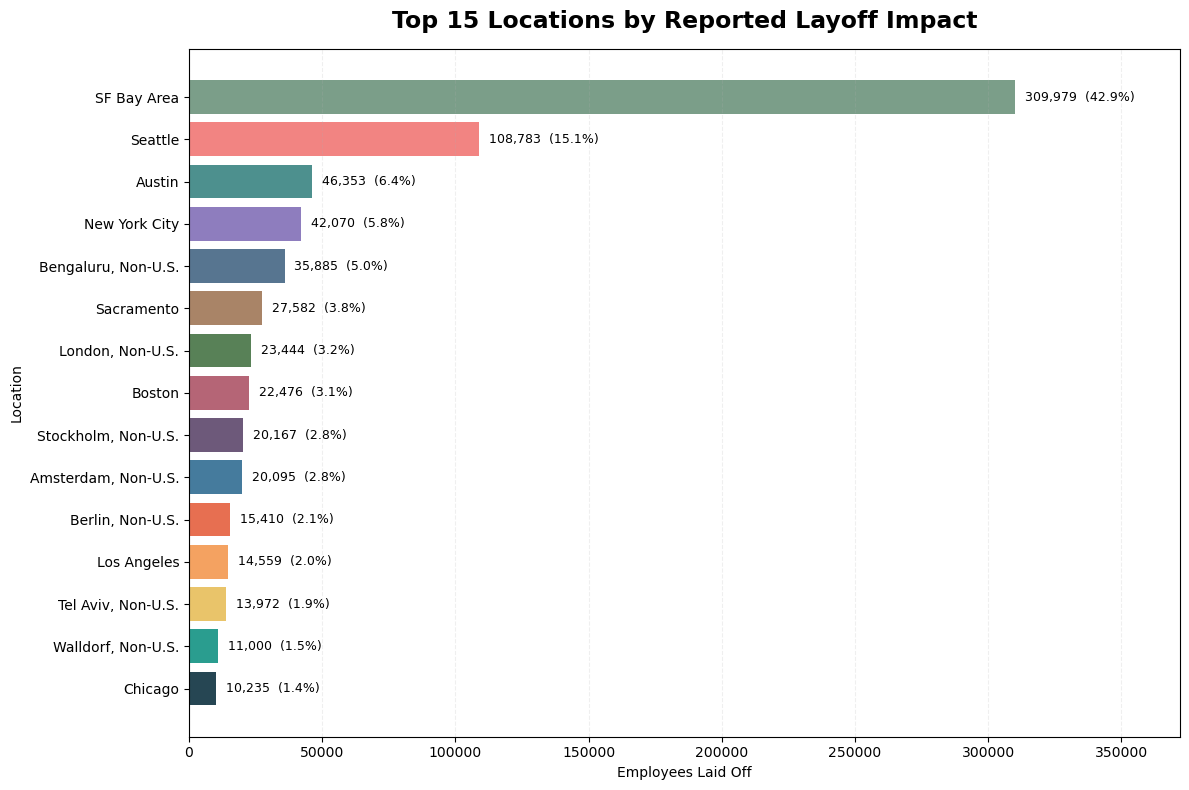

In [72]:
plt.figure(figsize=(12, 8))

location_sorted = location_layoffs.sort_values()

# Professional color palette — one color per bar
colors = [
    '#264653',
    '#2A9D8F',
    '#E9C46A',
    '#F4A261',
    '#E76F51',
    '#457B9D',
    '#6D597A',
    '#B56576',
    '#588157',
    '#A98467',
    '#577590',
    '#8E7DBE',
    '#4D908E',
    '#F28482',
    '#7B9E89'
]

bars = plt.barh(
    location_sorted.index,
    location_sorted.values,
    color=colors
)

total_top15 = location_sorted.sum()

# Add numbers + percentage
for bar in bars:
    value = bar.get_width()
    share = (value / total_top15) * 100

    plt.text(
        value + location_sorted.max() * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,.0f}  ({share:.1f}%)',
        va='center',
        fontsize=9
    )

plt.title(
    'Top 15 Locations by Reported Layoff Impact',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel('Employees Laid Off')
plt.ylabel('Location')

# Extra space for labels
plt.xlim(
    0,
    location_sorted.max() * 1.20
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [73]:
#Analysis 11 — Layoffs by Industry Over Time

industry_year = (
    df_clean.groupby([
        df_clean['date'].dt.year,
        'industry'
    ])['total_laid_off']
    .sum()
    .reset_index()
)

industry_year.columns = [
    'year',
    'industry',
    'total_laid_off'
]

industry_year.head(20)

,year,industry,total_laid_off
0,2020,Aerospace,561.0
1,2020,Construction,896.0
2,2020,Consumer,6063.0
3,2020,Crypto,91.0
4,2020,Data,1268.0
5,2020,Education,685.0
6,2020,Energy,167.0
7,2020,Finance,8624.0
8,2020,Fitness,3142.0
9,2020,Food,6218.0


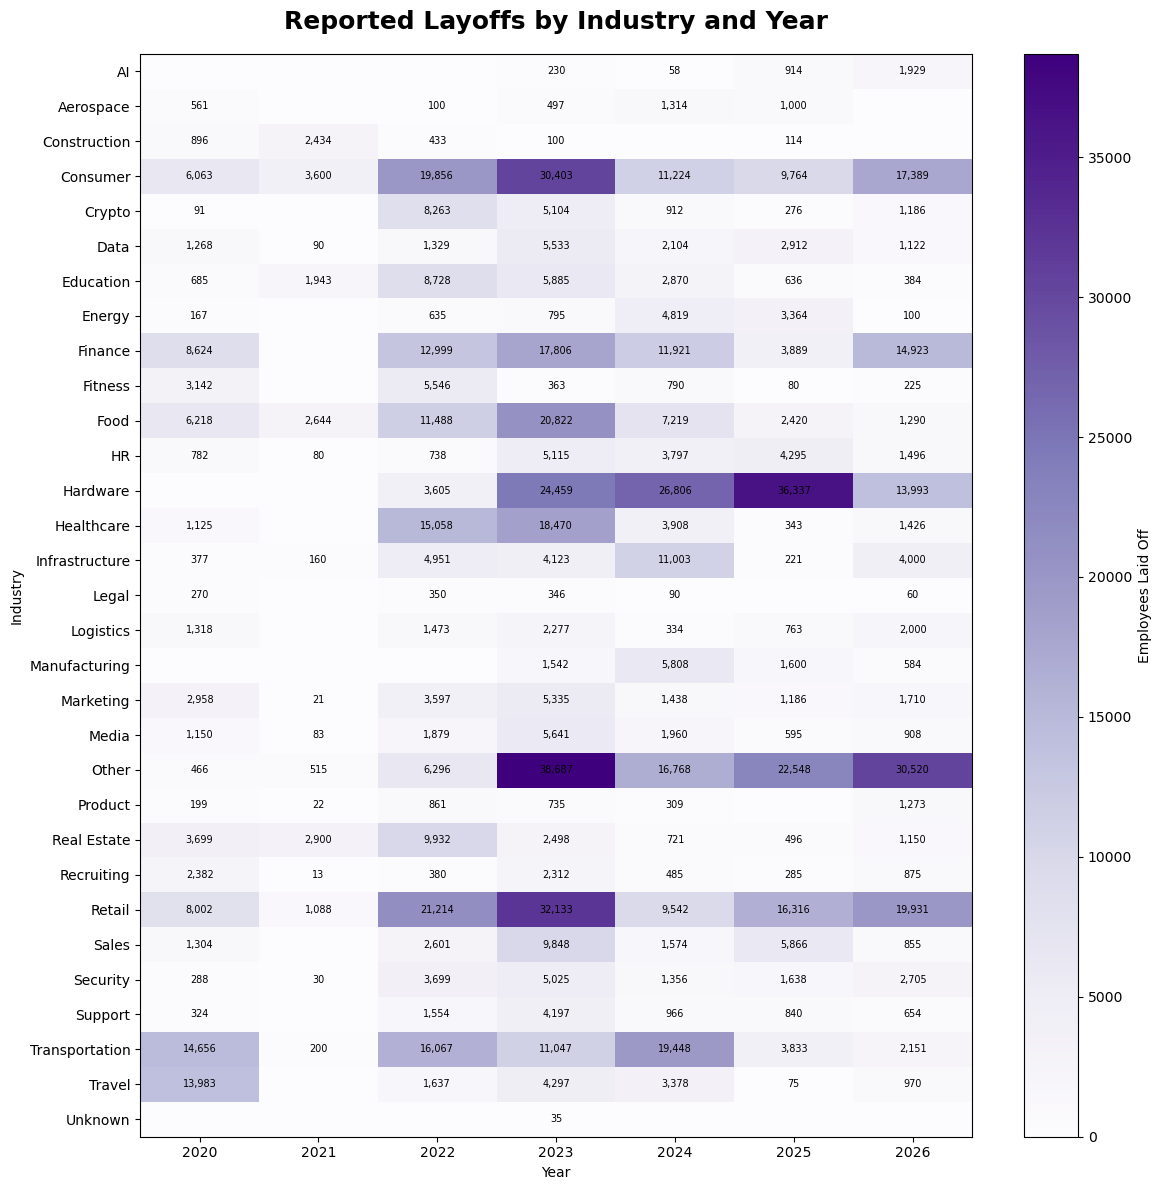

In [79]:
industry_heatmap = industry_year.pivot(
    index='industry',
    columns='year',
    values='total_laid_off'
).fillna(0)

plt.figure(figsize=(12, 12))

plt.imshow(
    industry_heatmap,
    aspect='auto',
    cmap='Purples'
)

plt.xticks(
    range(len(industry_heatmap.columns)),
    industry_heatmap.columns
)

plt.yticks(
    range(len(industry_heatmap.index)),
    industry_heatmap.index
)

plt.xlabel('Year')
plt.ylabel('Industry')

plt.title(
    'Reported Layoffs by Industry and Year',
    fontsize=18,
    fontweight='bold',
    pad=18
)

# Add exact values inside cells
for i in range(len(industry_heatmap.index)):
    for j in range(len(industry_heatmap.columns)):

        value = industry_heatmap.iloc[i, j]

        if value > 0:
            plt.text(
                j,
                i,
                f'{value:,.0f}',
                ha='center',
                va='center',
                fontsize=7
            )

cbar = plt.colorbar()
cbar.set_label('Employees Laid Off')

plt.tight_layout()
plt.show()

In [80]:
# Analysis 12 — Which industries had the highest average layoff severity?
industry_severity = (
    df_clean.groupby('industry')['percentage_laid_off']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
)

industry_severity.head(15)

,mean,median,count
industry,,,
Aerospace,0.454000,0.250,15
Food,0.397036,0.200,167
AI,0.391818,0.230,22
Energy,0.372000,0.250,30
Construction,0.365882,0.160,17
Healthcare,0.348165,0.205,218
Education,0.338936,0.200,94
Travel,0.336377,0.220,69
Real Estate,0.335258,0.220,97


In [83]:
industry_severity_50 = (
    industry_severity[
        industry_severity['count'] >= 50
    ]
    .sort_values('mean', ascending=False)
    .copy()
)

# Convert proportions to percentages and round to 1 decimal
industry_severity_50['mean'] = (
    industry_severity_50['mean'] * 100
).round(1)

industry_severity_50['median'] = (
    industry_severity_50['median'] * 100
).round(1)

industry_severity_50

,mean,median,count
industry,,,
Food,39.7,20.0,167
Healthcare,34.8,20.5,218
Education,33.9,20.0,94
Travel,33.6,22.0,69
Real Estate,33.5,22.0,97
Retail,31.8,18.5,222
Crypto,31.5,20.0,135
Transportation,30.6,17.0,182
Finance,29.8,19.0,358


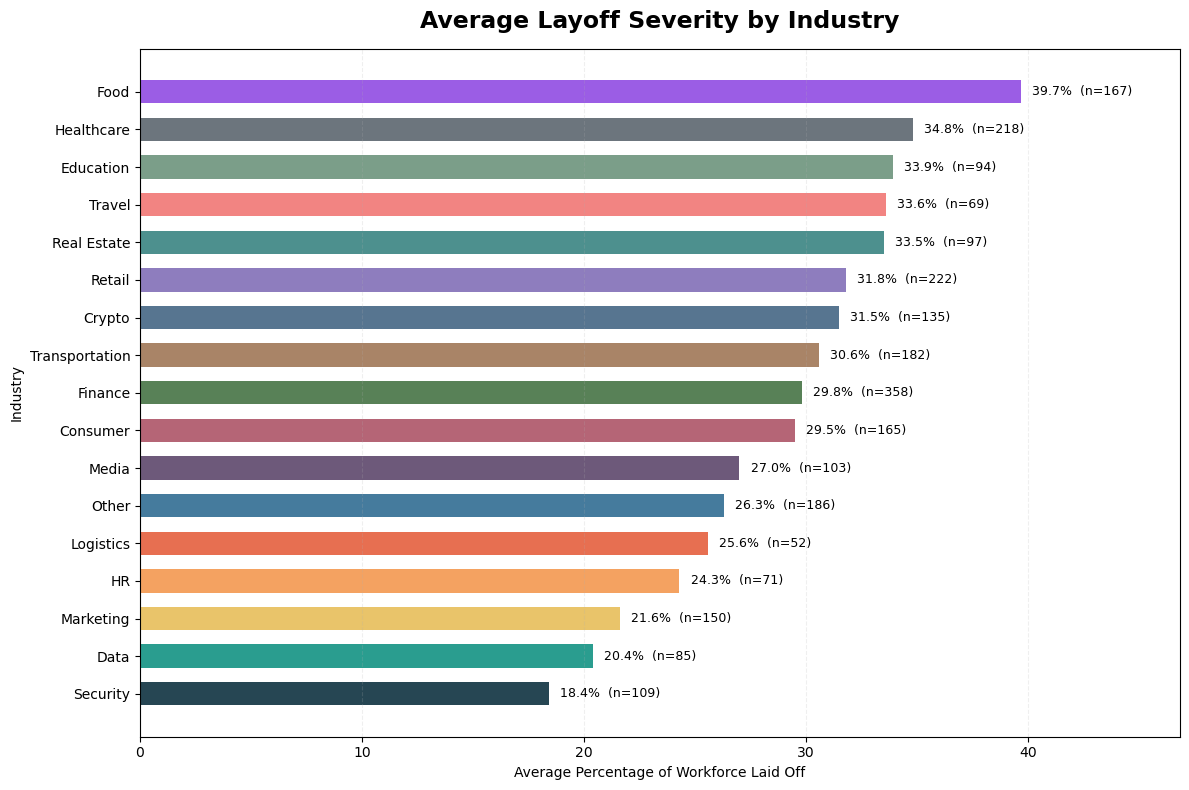

In [85]:
plt.figure(figsize=(12, 8))

severity_sorted = industry_severity_50.sort_values('mean')

# Different color for each bar
colors = [
    '#264653', '#2A9D8F', '#E9C46A', '#F4A261',
    '#E76F51', '#457B9D', '#6D597A', '#B56576',
    '#588157', '#A98467', '#577590', '#8E7DBE',
    '#4D908E', '#F28482', '#7B9E89', '#6C757D',
    '#9B5DE5'
]

bars = plt.barh(
    severity_sorted.index,
    severity_sorted['mean'],
    height=0.62,
    color=colors[:len(severity_sorted)]
)

# Add percentage + sample size
for bar, count in zip(bars, severity_sorted['count']):

    value = bar.get_width()

    plt.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%  (n={count})',
        va='center',
        fontsize=9
    )

plt.title(
    'Average Layoff Severity by Industry',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Average Percentage of Workforce Laid Off'
)

plt.ylabel('Industry')

# Extra space for labels
plt.xlim(
    0,
    severity_sorted['mean'].max() * 1.18
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [86]:
# Analysis 13 — Companies with Repeated Layoff Events

company_events = (
    df_clean.groupby('company')
    .agg(
        layoff_events=('date', 'count'),
        total_laid_off=('total_laid_off', 'sum')
    )
    .sort_values(
        ['layoff_events', 'total_laid_off'],
        ascending=False
    )
)

company_events.head(20)

,layoff_events,total_laid_off
company,,
Amazon,22,59291.0
Google,19,13749.0
Microsoft,17,34855.0
Salesforce,14,16611.0
Intel,12,43115.0
Meta,12,35700.0
Rivian,12,2110.0
Oracle,11,22294.0
TikTok,10,2160.0


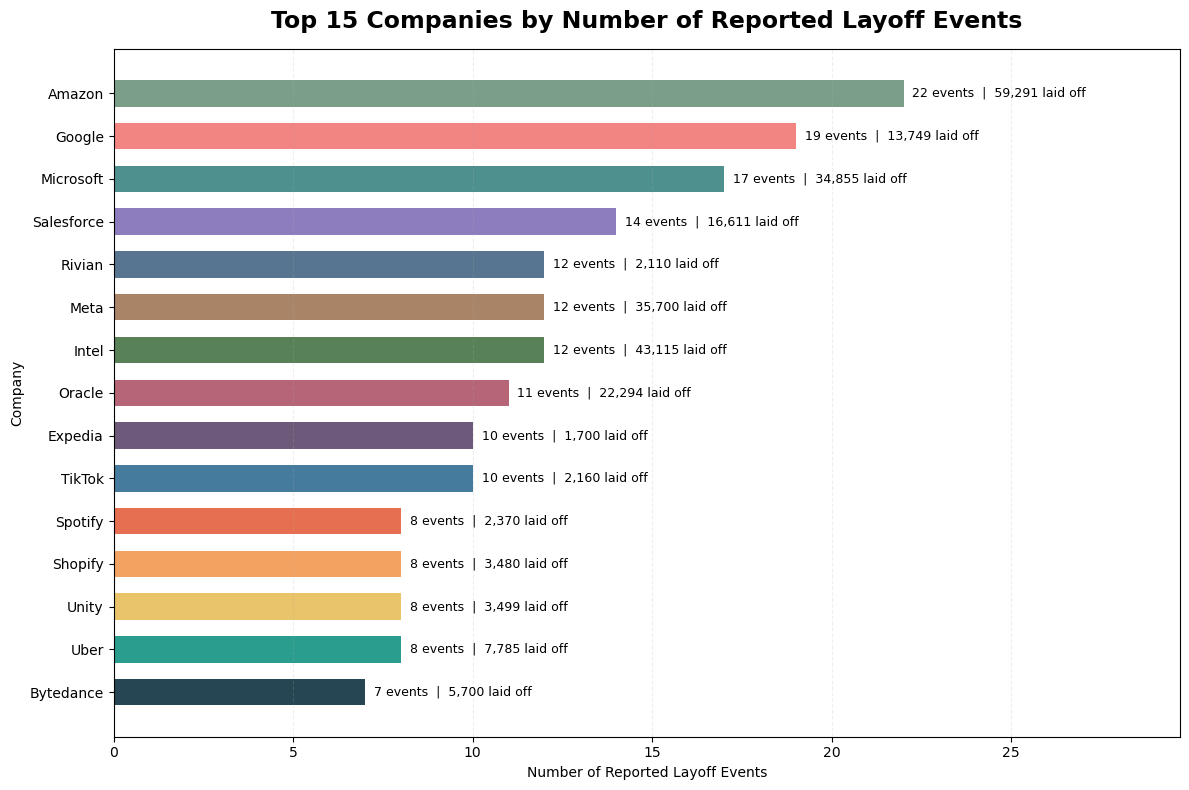

In [87]:
# ANALYSIS 13 - Top 15 companies by number of layoff events
top_repeated = company_events.head(15).sort_values('layoff_events')

plt.figure(figsize=(12, 8))

# Different colors for each company
colors = [
    '#264653', '#2A9D8F', '#E9C46A', '#F4A261',
    '#E76F51', '#457B9D', '#6D597A', '#B56576',
    '#588157', '#A98467', '#577590', '#8E7DBE',
    '#4D908E', '#F28482', '#7B9E89'
]

bars = plt.barh(
    top_repeated.index,
    top_repeated['layoff_events'],
    height=0.62,
    color=colors[:len(top_repeated)]
)

# Add event count + total layoffs
for bar, total in zip(bars, top_repeated['total_laid_off']):

    events = bar.get_width()

    plt.text(
        events + 0.25,
        bar.get_y() + bar.get_height() / 2,
        f'{events:.0f} events  |  {total:,.0f} laid off',
        va='center',
        fontsize=9
    )

plt.title(
    'Top 15 Companies by Number of Reported Layoff Events',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel('Number of Reported Layoff Events')
plt.ylabel('Company')

# Extra room for labels
plt.xlim(
    0,
    top_repeated['layoff_events'].max() * 1.35
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [88]:
# Analysis 14 - Does company stage relate to layoff severity?

stage_severity = (
    df_clean.groupby('stage')['percentage_laid_off']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
)

stage_severity

,mean,median,count
stage,,,
Seed,0.831707,1.000,123
Series A,0.475281,0.330,178
Unknown,0.378004,0.200,456
Series B,0.358754,0.250,329
Acquired,0.328337,0.165,196
Subsidiary,0.264706,0.150,17
Series C,0.253322,0.180,286
Series D,0.202067,0.150,254
Series E,0.183404,0.130,141


In [89]:
stage_severity_clean = (
    stage_severity[
        (stage_severity['count'] >= 20) &
        (stage_severity.index != 'Unknown')
    ]
    .sort_values('mean', ascending=False)
    .copy()
)

# Convert to percentages and round
stage_severity_clean['mean'] = (
    stage_severity_clean['mean'] * 100
).round(1)

stage_severity_clean['median'] = (
    stage_severity_clean['median'] * 100
).round(1)

stage_severity_clean

,mean,median,count
stage,,,
Seed,83.2,100.0,123
Series A,47.5,33.0,178
Series B,35.9,25.0,329
Acquired,32.8,16.5,196
Series C,25.3,18.0,286
Series D,20.2,15.0,254
Series E,18.3,13.0,141
Private Equity,18.0,10.0,51
Post-IPO,16.5,10.0,687


C:\Users\shalini\AppData\Local\Temp\ipykernel_5320\2483901547.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


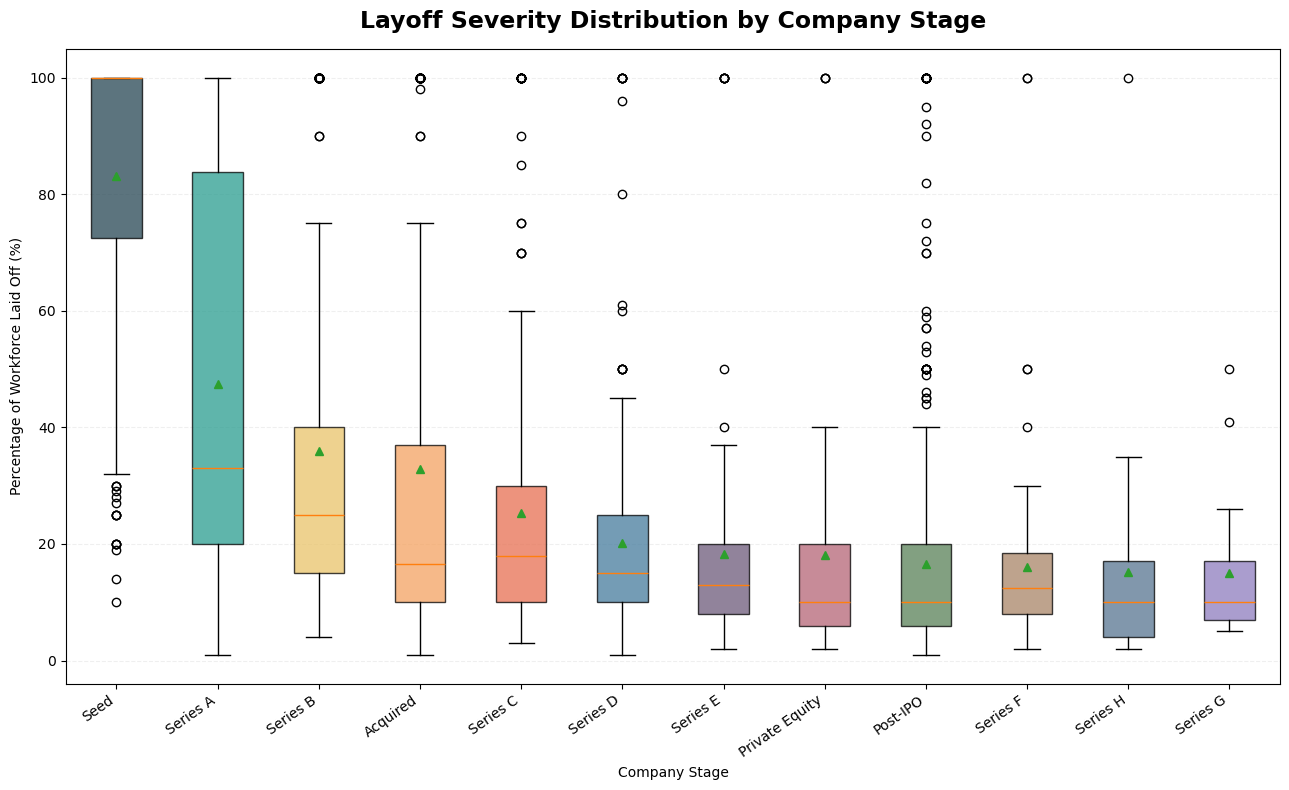

In [95]:
# Keep only valid stages with at least 20 observations
valid_stages = stage_severity_clean.index

boxplot_data = [
    df_clean.loc[
        df_clean['stage'] == stage,
        'percentage_laid_off'
    ].dropna() * 100
    for stage in valid_stages
]

plt.figure(figsize=(13, 8))

bp = plt.boxplot(
    boxplot_data,
    labels=valid_stages,
    patch_artist=True,
    showmeans=True
)

# Give each box a different color
colors = [
    '#264653', '#2A9D8F', '#E9C46A', '#F4A261',
    '#E76F51', '#457B9D', '#6D597A', '#B56576',
    '#588157', '#A98467', '#577590', '#8E7DBE',
    '#4D908E'
]

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

plt.title(
    'Layoff Severity Distribution by Company Stage',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel('Company Stage')
plt.ylabel('Percentage of Workforce Laid Off (%)')

plt.xticks(
    range(1, len(valid_stages) + 1),
    valid_stages,
    rotation=35,
    ha='right'
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [96]:
# Analysis 15 — Funding Level vs. Layoff Impact
funding_df = df_clean[
    df_clean['funds_raised'].notna() &
    df_clean['total_laid_off'].notna()
].copy()

funding_df['funding_level'] = pd.cut(
    funding_df['funds_raised'],
    bins=[0, 10, 50, 100, 500, np.inf],
    labels=[
        'Under $10M',
        '$10M–$50M',
        '$50M–$100M',
        '$100M–$500M',
        '$500M+'
    ]
)

funding_analysis = (
    funding_df.groupby(
        'funding_level',
        observed=True
    )
    .agg(
        avg_laid_off=('total_laid_off', 'mean'),
        median_laid_off=('total_laid_off', 'median'),
        companies=('company', 'count')
    )
)

funding_analysis

,avg_laid_off,median_laid_off,companies
funding_level,,,
Under $10M,502.486111,60.0,144
$10M–$50M,244.649880,44.0,417
$50M–$100M,157.208696,50.0,345
$100M–$500M,182.304306,83.0,1045
$500M+,500.911142,180.0,709


In [99]:
funding_analysis.rename(
    index={
        'Under $10M': 'Under 10M',
        '$10M–$50M': '10M–50M',
        '$50M–$100M': '50M–100M',
        '$100M–$500M': '100M–500M',
        '$500M+': '500M+'
    }
)

,avg_laid_off,median_laid_off,companies
Under 10M,502.486111,60.0,144
10M–50M,244.649880,44.0,417
50M–100M,157.208696,50.0,345
100M–500M,182.304306,83.0,1045
500M+,500.911142,180.0,709


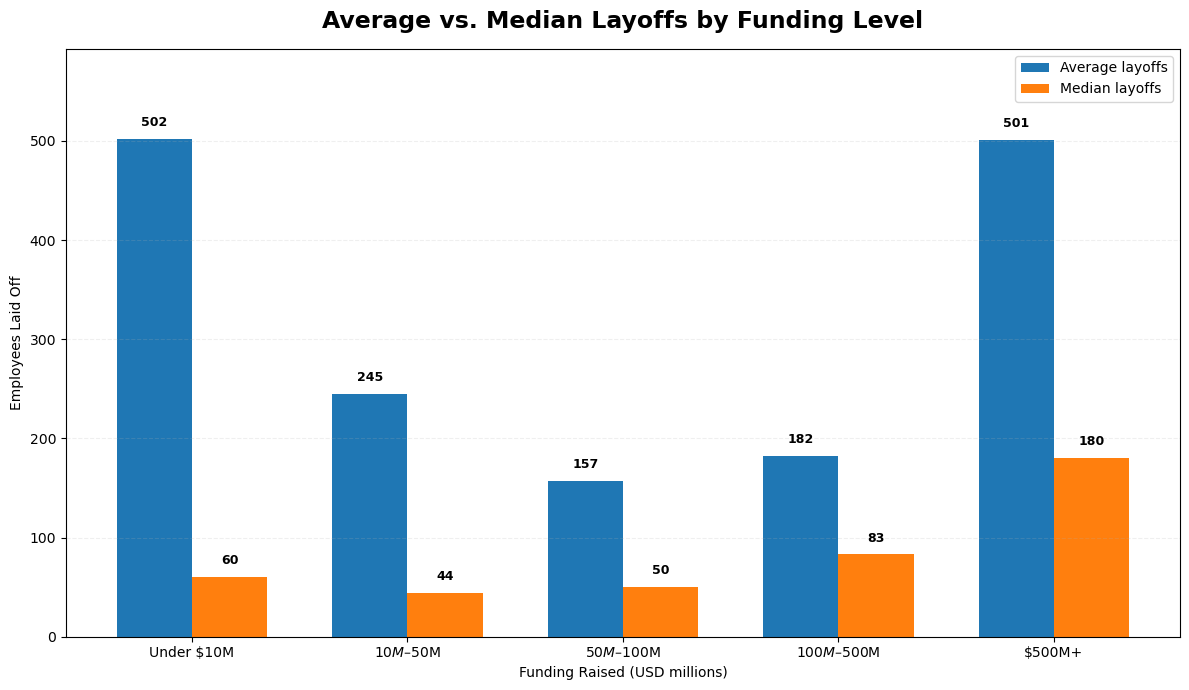

In [100]:
plt.figure(figsize=(12, 7))

x = np.arange(len(funding_analysis.index))
width = 0.35

# Mean bars
bars1 = plt.bar(
    x - width / 2,
    funding_analysis['avg_laid_off'],
    width,
    label='Average layoffs'
)

# Median bars
bars2 = plt.bar(
    x + width / 2,
    funding_analysis['median_laid_off'],
    width,
    label='Median layoffs'
)

# Add values above bars
for bars in [bars1, bars2]:
    for bar in bars:
        value = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 10,
            f'{value:,.0f}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

plt.title(
    'Average vs. Median Layoffs by Funding Level',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel('Funding Raised (USD millions)')
plt.ylabel('Employees Laid Off')

plt.xticks(
    x,
    funding_analysis.index
)

# Room for labels
plt.ylim(
    0,
    funding_analysis['avg_laid_off'].max() * 1.18
)

plt.legend()

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [102]:
# Analysis 16 — Country × Industry
country_industry = (
    df_clean.groupby(
        ['country', 'industry']
    )['total_laid_off']
    .sum()
    .reset_index()
)

country_industry.head(20)

,country,industry,total_laid_off
0,Argentina,Crypto,180.0
1,Argentina,Finance,53.0
2,Argentina,Food,0.0
3,Argentina,Marketing,50.0
4,Argentina,Other,40.0
5,Australia,Construction,0.0
6,Australia,Consumer,120.0
7,Australia,Crypto,301.0
8,Australia,Data,0.0
9,Australia,Energy,88.0


In [103]:
top_countries = (
    df_clean.groupby('country')['total_laid_off']
    .sum()
    .nlargest(10)
    .index
)

country_industry_top10 = country_industry[
    country_industry['country'].isin(top_countries)
].copy()

country_industry_top10

,country,industry,total_laid_off
33,Brazil,Consumer,381.0
34,Brazil,Crypto,190.0
35,Brazil,Education,319.0
36,Brazil,Finance,4251.0
37,Brazil,Fitness,467.0
...,...,...,...
425,United States,Security,12399.0
426,United States,Support,7721.0
427,United States,Transportation,47722.0
428,United States,Travel,12029.0


In [104]:
top_industries = (
    df_clean.groupby('industry')['total_laid_off']
    .sum()
    .nlargest(10)
    .index
)

country_industry_top10 = country_industry_top10[
    country_industry_top10['industry'].isin(top_industries)
].copy()

country_industry_matrix = country_industry_top10.pivot(
    index='country',
    columns='industry',
    values='total_laid_off'
).fillna(0)

country_industry_matrix

industry,Consumer,Finance,Food,Hardware,Healthcare,Infrastructure,Other,Retail,Transportation,Travel
country,,,,,,,,,,
Brazil,381.0,4251.0,775.0,0.0,311.0,0.0,243.0,856.0,445.0,749.0
Canada,22.0,1372.0,1781.0,130.0,407.0,30.0,346.0,5158.0,387.0,272.0
China,3445.0,0.0,0.0,1970.0,500.0,0.0,1500.0,0.0,0.0,0.0
Germany,400.0,942.0,9878.0,0.0,81.0,0.0,12207.0,1904.0,999.0,105.0
India,7348.0,9941.0,8187.0,0.0,2857.0,0.0,1550.0,7037.0,7170.0,2500.0
Israel,2965.0,1787.0,540.0,290.0,555.0,0.0,613.0,1223.0,735.0,20.0
Netherlands,0.0,150.0,1140.0,1700.0,10000.0,0.0,885.0,300.0,725.0,4975.0
Sweden,350.0,1004.0,70.0,0.0,400.0,0.0,10250.0,270.0,385.0,0.0
United Kingdom,79.0,3975.0,10404.0,100.0,427.0,0.0,580.0,2159.0,2673.0,1124.0


In [106]:
# Work from the country × industry matrix
country_industry_plot = country_industry_matrix.copy()

# Find the top 5 industries within each country
plot_data = pd.DataFrame(
    index=country_industry_plot.index
)

for country in country_industry_plot.index:

    top5 = (
        country_industry_plot.loc[country]
        .nlargest(5)
    )

    plot_data.loc[country, top5.index] = top5

# Replace missing values with 0
plot_data = plot_data.fillna(0)

# Everything not in a country's top 5 becomes Other
plot_data['Other'] = (
    country_industry_plot.sum(axis=1)
    - plot_data.sum(axis=1)
)

plot_data

,Finance,Retail,Food,Travel,Transportation,Healthcare,Consumer,Hardware,Other
country,,,,,,,,,
Brazil,4251.0,856.0,775.0,749.0,445.0,0.0,0.0,0.0,935.0
Canada,1372.0,5158.0,1781.0,0.0,387.0,407.0,0.0,0.0,800.0
China,0.0,0.0,0.0,0.0,0.0,500.0,3445.0,1970.0,0.0
Germany,942.0,1904.0,9878.0,0.0,999.0,0.0,0.0,0.0,586.0
India,9941.0,7037.0,8187.0,0.0,7170.0,0.0,7348.0,0.0,6907.0
Israel,1787.0,1223.0,0.0,0.0,735.0,0.0,2965.0,0.0,1405.0
Netherlands,0.0,0.0,1140.0,4975.0,0.0,10000.0,0.0,1700.0,1175.0
Sweden,1004.0,0.0,0.0,0.0,385.0,400.0,350.0,0.0,340.0
United Kingdom,3975.0,2159.0,10404.0,1124.0,2673.0,0.0,0.0,0.0,1186.0


In [107]:
# Top 5 industries overall
top5_industries = (
    df_clean.groupby('industry')['total_laid_off']
    .sum()
    .nlargest(5)
    .index
)

# Keep only those industries
country_industry_plot = country_industry_matrix[
    top5_industries
].copy()

# Combine all remaining industries into "Other"
country_industry_plot['Other'] = (
    country_industry_matrix.sum(axis=1)
    - country_industry_plot.sum(axis=1)
)

country_industry_plot

industry,Other,Retail,Hardware,Consumer,Finance
country,,,,,
Brazil,2280.0,856.0,0.0,381.0,4251.0
Canada,2877.0,5158.0,130.0,22.0,1372.0
China,500.0,0.0,1970.0,3445.0,0.0
Germany,11063.0,1904.0,0.0,400.0,942.0
India,20714.0,7037.0,0.0,7348.0,9941.0
Israel,1850.0,1223.0,290.0,2965.0,1787.0
Netherlands,16840.0,300.0,1700.0,0.0,150.0
Sweden,855.0,270.0,0.0,350.0,1004.0
United Kingdom,14628.0,2159.0,100.0,79.0,3975.0


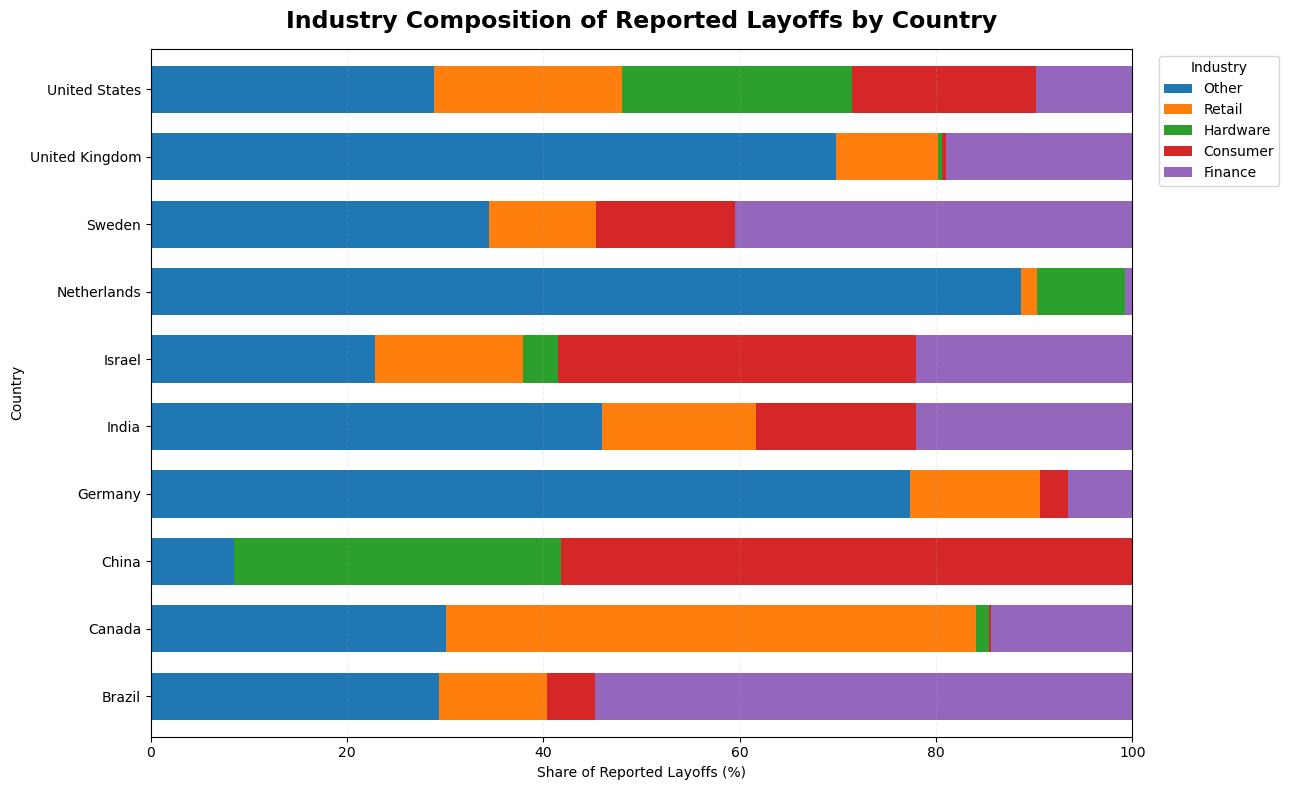

In [108]:
# Convert each country's values into percentages
country_industry_pct = (
    country_industry_plot
    .div(country_industry_plot.sum(axis=1), axis=0)
    * 100
)

# Plot
ax = country_industry_pct.plot(
    kind='barh',
    stacked=True,
    figsize=(13, 8),
    width=0.7
)

plt.title(
    'Industry Composition of Reported Layoffs by Country',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel('Share of Reported Layoffs (%)')
plt.ylabel('Country')

plt.xlim(0, 100)

plt.legend(
    title='Industry',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [109]:
# Analysis 17 — Layoff Events vs. Layoff Severity

company_severity = (
    df_clean[
        df_clean['percentage_laid_off'].notna()
    ]
    .groupby('company')
    .agg(
        layoff_events=('date', 'count'),
        avg_severity=('percentage_laid_off', 'mean'),
        total_laid_off=('total_laid_off', 'sum')
    )
)

# Keep companies with at least 3 reported events
company_severity = (
    company_severity[
        company_severity['layoff_events'] >= 3
    ]
    .copy()
)

# Convert severity to percentage
company_severity['avg_severity'] = (
    company_severity['avg_severity'] * 100
).round(1)

company_severity.head(20)

,layoff_events,avg_severity,total_laid_off
company,,,
23andMe,3,20.0,346.0
Amazon,3,2.0,32000.0
Amdocs,3,5.3,2700.0
Aqua Security,3,9.7,139.0
Arrival,4,51.2,800.0
Astra,4,41.5,146.0
Augury,3,13.7,150.0
Autodesk,3,6.0,2600.0
Away,3,14.3,82.0


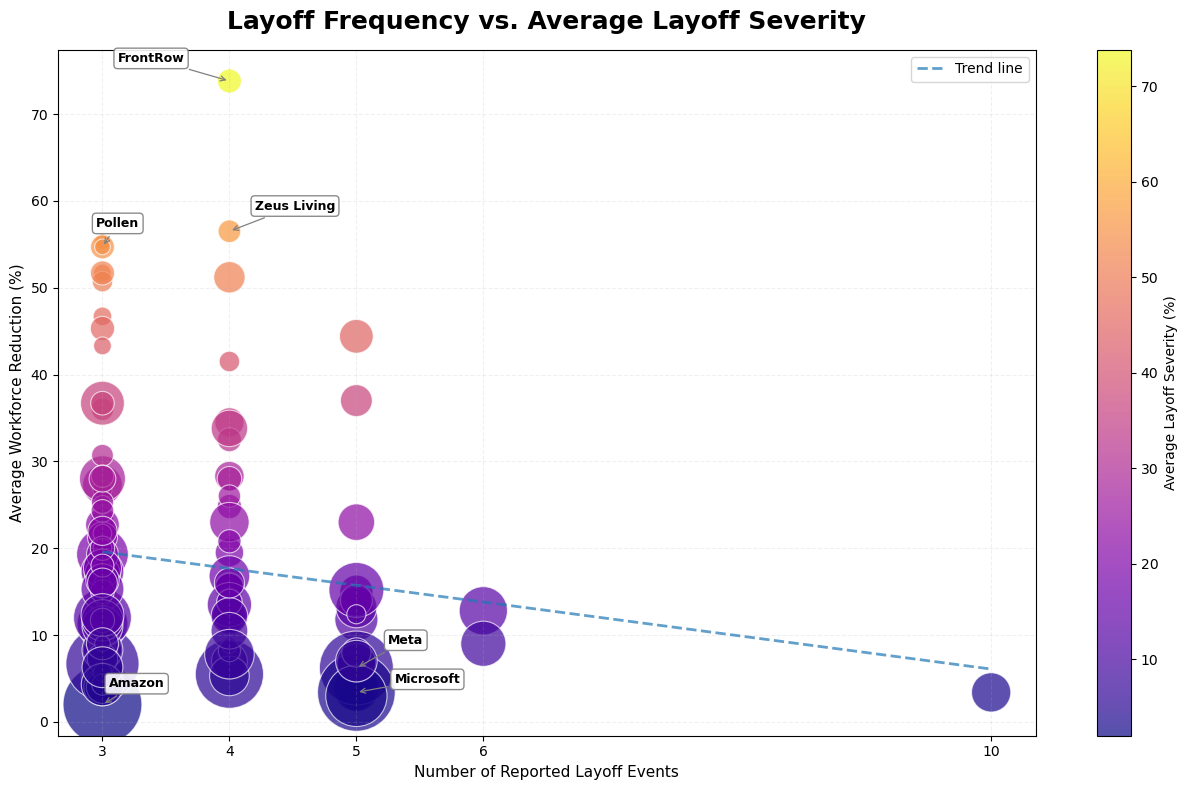

In [116]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(13, 8))

# Bubble sizes
bubble_size = np.sqrt(
    company_severity['total_laid_off'].clip(lower=50)
) * 18

scatter = plt.scatter(
    company_severity['layoff_events'],
    company_severity['avg_severity'],
    s=bubble_size,
    c=company_severity['avg_severity'],
    cmap='plasma',
    alpha=0.70,
    edgecolors='white',
    linewidth=0.8
)

# -----------------------------
# Trend line
# -----------------------------

x = company_severity['layoff_events'].values
y = company_severity['avg_severity'].values

z = np.polyfit(x, y, 1)
trend = np.poly1d(z)

x_line = np.linspace(x.min(), x.max(), 100)

plt.plot(
    x_line,
    trend(x_line),
    '--',
    linewidth=2,
    alpha=0.7,
    label='Trend line'
)

# -----------------------------
# Manual label positions
# -----------------------------

label_positions = {
    'FrontRow': (3.12, 76),
    'Pollen': (2.95, 57),
    'Zeus Living': (4.20, 59),
    'Amazon': (3.05, 4.0),
    'Meta': (5.25, 9.0),
    'Microsoft': (5.30, 4.5),
    'Tesla': (9.55, 6.0)
}

# -----------------------------
# Add labels
# -----------------------------

for company, (label_x, label_y) in label_positions.items():

    if company in company_severity.index:

        row = company_severity.loc[company]

        plt.annotate(
            company,
            xy=(
                row['layoff_events'],
                row['avg_severity']
            ),
            xytext=(
                label_x,
                label_y
            ),
            fontsize=9,
            fontweight='bold',
            bbox=dict(
                boxstyle='round,pad=0.3',
                facecolor='white',
                edgecolor='gray',
                alpha=0.9
            ),
            arrowprops=dict(
                arrowstyle='->',
                color='gray',
                lw=0.9
            )
        )

# -----------------------------
# Titles
# -----------------------------

plt.title(
    'Layoff Frequency vs. Average Layoff Severity',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Number of Reported Layoff Events',
    fontsize=11
)

plt.ylabel(
    'Average Workforce Reduction (%)',
    fontsize=11
)

# -----------------------------
# Colorbar
# -----------------------------

cbar = plt.colorbar(scatter)

cbar.set_label(
    'Average Layoff Severity (%)'
)

# -----------------------------
# Formatting
# -----------------------------

plt.xticks(
    sorted(company_severity['layoff_events'].unique())
)

plt.grid(
    linestyle='--',
    alpha=0.18
)

plt.legend(
    loc='upper right'
)

plt.tight_layout()

plt.show()

In [118]:
# Analysis 18 — Average Layoffs per Event by Industry

industry_event_analysis = (
    df_clean.groupby('industry')
    .agg(
        total_laid_off=('total_laid_off', 'sum'),
        layoff_events=('company', 'count')
    )
)

industry_event_analysis['avg_laid_off_per_event'] = (
    industry_event_analysis['total_laid_off']
    / industry_event_analysis['layoff_events']
)

# Keep industries with at least 10 reported events
industry_event_analysis = (
    industry_event_analysis[
        industry_event_analysis['layoff_events'] >= 10
    ]
    .sort_values(
        'avg_laid_off_per_event',
        ascending=False
    )
)

industry_event_analysis

,total_laid_off,layoff_events,avg_laid_off_per_event
industry,,,
Hardware,105200.0,85,1237.647059
Other,115800.0,307,377.198697
Infrastructure,24835.0,79,314.367089
Consumer,98299.0,314,313.054140
Retail,108226.0,362,298.966851
Manufacturing,9534.0,33,288.909091
Sales,22048.0,77,286.337662
Transportation,67402.0,274,245.992701
Travel,24340.0,113,215.398230


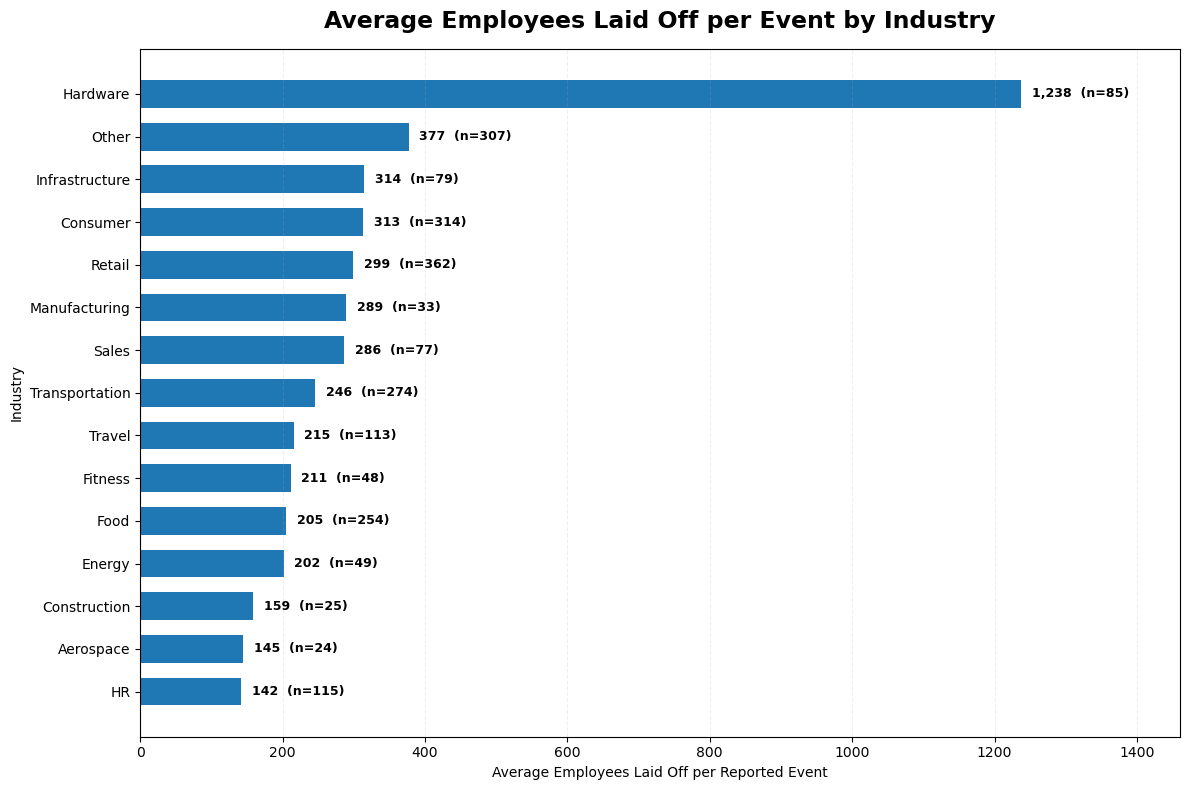

In [119]:
import matplotlib.pyplot as plt

# Top 15 industries by average layoffs per event
plot_data = (
    industry_event_analysis
    .nlargest(15, 'avg_laid_off_per_event')
    .sort_values('avg_laid_off_per_event')
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    plot_data.index,
    plot_data['avg_laid_off_per_event'],
    height=0.65
)

# Add values + event counts
for bar, value, events in zip(
    bars,
    plot_data['avg_laid_off_per_event'],
    plot_data['layoff_events']
):
    
    plt.text(
        value + 15,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,.0f}  (n={events})',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title(
    'Average Employees Laid Off per Event by Industry',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Average Employees Laid Off per Reported Event'
)

plt.ylabel(
    'Industry'
)

# Give labels room
plt.xlim(
    0,
    plot_data['avg_laid_off_per_event'].max() * 1.18
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.2
)

plt.tight_layout()

plt.show()